## Libraries

In [46]:
import os
import sys
import shutil
import ast
import copy
import time
import numpy as np
import pandas as pd
import datetime as dt
import glob

import re
from collections import Counter
from collections import OrderedDict
import itertools
from itertools import product

import matplotlib as mpl
import matplotlib.pylab as pl
from matplotlib.collections import LineCollection, EllipseCollection
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionStyle
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import Normalize, LogNorm, SymLogNorm
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
from matplotlib.patches import Patch
from matplotlib.patches import Polygon
import matplotlib.transforms as mtransforms
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path        # <-- Path defined here
import matplotlib.dates as mdates
from matplotlib.table import Table
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from joypy import joyplot
import contextily as ctx
from shapely.geometry import box, Point, LineString
import geopandas as gpd
from pyproj import Transformer

from scipy.stats import entropy
from scipy.stats import zscore
from scipy.stats import norm
from scipy.stats import gaussian_kde

import importlib

from Modules import analysis, config
from Modules import data_figures

#reload modules
importlib.reload(analysis)
importlib.reload(config)
importlib.reload(data_figures)

#refresh namespace
from Modules.analysis import *
from Modules import config

## Experimental data

__CSV TABLES__

In [21]:
FOLD_save = 'Data_experiments/'

files = [#DATA FOR FIGURES IN THE MAIN AND SUPPLEMENTARY
         'df_trajectory_record_indicator.csv',
         'df_user_contact_count.csv',
         'df_emo_metrics_debiasing.csv',
         'df_emo_metrics_sparsification.csv',
         'df_calibration_biased.csv',
         'df_calibration_corrected.csv', 
         'df_R0_grid_estimates.csv',
         #DATA USED FOR SUPPLEMENTARY FIGURES
         'df_supp_contact_count_change-duration.csv',
         'df_supp_contact_count_sparsification.csv',
         'df_supp_contact_average_duration_sparsification.csv',
         'df_supp_contact_average_R0_sparsification.csv',
         'df_supp_contact_average_duration_data-driven_biased-corrected.csv',
         'df_supp_contact_average_R0_data-driven_biased-corrected.csv'] 

DICT_data = {}
for f in files:
    print(f)
    DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)

#[2] DATASET COLUMNS 
cols_sparsity = ['sparsity', 'sparsity_level', 'modeling_type']
cols_metrics_size = ['size_peak', 'size_total'] 
cols_metrics_dynamic = ['day_peak', 'day_last_case','day_last_recovery'] 
cols_metrics = cols_metrics_size + cols_metrics_dynamic
cols_iter = ['iter_sparsity']
cols_tot = cols_metrics + cols_sparsity + cols_iter

cols_metrics_dynamic_rename = ['Day of peak', 'Day of last case', 'Day of last recovery']
dict_metrics_dynamic_rename = dict(zip(cols_metrics_dynamic, cols_metrics_dynamic_rename))

df_trajectory_record_indicator.csv
df_user_contact_count.csv
df_emo_metrics_debiasing.csv
df_emo_metrics_sparsification.csv
df_calibration_biased.csv
df_calibration_corrected.csv
df_R0_grid_estimates.csv
df_supp_contact_count_change-duration.csv
df_supp_contact_count_sparsification.csv
df_supp_contact_average_duration_sparsification.csv
df_supp_contact_average_R0_sparsification.csv
df_supp_contact_average_duration_data-driven_biased-corrected.csv
df_supp_contact_average_R0_data-driven_biased-corrected.csv


/tmp/ipykernel_2959759/574784083.py:22: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)
/tmp/ipykernel_2959759/574784083.py:22: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)


In [31]:
DICT_data['calibration_biased'][['beta','gamma']].describe().loc[['min','max']]

,beta,gamma
min,0.643252,0.218251
max,8.429889,0.299315


In [32]:
df_calibration_outcomes = data_figures.load_calibration_info(fold = config.FOLD_DTU)

In [34]:
df_calibration_outcomes.head(2)

,beta,gamma,seedsize,best_value,iter,sparsity,level,contacts_type
0,2.689522,0.272522,2,49.748441,1,Data_driven,"(0.1, 0.2)",sparse
1,2.012133,0.217225,3,49.663497,1,Data_driven,"(0.1, 0.2)",corrected


In [36]:
df_calibration_outcomes = df_calibration_outcomes[df_calibration_outcomes['contacts_type'] == 'corrected']

In [37]:
df_calibration_outcomes[['beta','gamma']].describe().loc[['min','max']]

,beta,gamma
min,1.676357,0.122822
max,7.174214,0.631376


In [28]:
pd.read_csv('Data_experiments/df_calibration_space.csv')

,Unnamed: 0,beta,gamma,seedsize
0,min,0.00005,0.117503,1.0
1,max,0.01000,0.632123,10.0


In [29]:
config.GRID_stats

,beta,gamma,seedsize
min,0.00005,0.117503,1.0
max,0.01000,0.632123,10.0


['Betas',
 'COLORS_LEVEL',
 'COLOR_A',
 'COLOR_B',
 'COLOR_BS',
 'COLOR_CALIB_BS',
 'COLOR_CALIB_CC',
 'COLOR_CC',
 'COLOR_GAPS',
 'COLOR_GT',
 'COLOR_R',
 'COLOR_RANDOM_SHUFFLING',
 'COLOR_RANDOM_UNIFORM',
 'COLOR_emvs',
 'Contact_corrections',
 'DICT_colors_emv',
 'DICT_colors_level',
 'DICT_colors_ss',
 'DICT_rename_EMVs',
 'DICT_rename_class_epid',
 'DICT_rename_contact_corrections',
 'DICT_rename_em_fraction',
 'DICT_rename_emo_metrics',
 'DICT_rename_emo_metrics_norm',
 'DICT_rename_levels',
 'DICT_rename_ss',
 'Dates',
 'Dates_plus1',
 'EMVs',
 'Emo_metrics_names',
 'FOLD_DTU',
 'FOLD_DTU_INPUT',
 'FOLD_SYNTH',
 'FOLD_SYNTH_INPUT',
 'GRID',
 'GRID_stats',
 'Gamma_max',
 'Gamma_min',
 'Gammas',
 'Level_colors',
 'Levels',
 'Levels_str',
 'List_emvs',
 'List_sparsity',
 'List_ss',
 'List_ss_rename',
 'N_inits',
 'N_users',
 'Ranges_iter',
 'Study_period',
 'Study_period_em',
 'Time_range',
 'USERS_select',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '_

In [ ]:
config.groundtruth_pars
def grid_shift_groundtruth_gamma_daily(df_GRID_v4_sub):
        #shift the grid such that it is centered on the ground truth
        b_gt, g_gt, ni_gt = [config.groundtruth_pars[c] for c in ['beta','gamma','seedsize']] 
        G_gt = 1 - (1-g_gt)**(60*24)
        df_GRID_v4_sub['delta_beta_gt']  = df_GRID_v4_sub['beta'] - b_gt
        df_GRID_v4_sub['delta_gamma_gt'] = df_GRID_v4_sub['gamma'] - G_gt
        df_closest = df_GRID_v4_sub.query("delta_beta_gt<0 & delta_gamma_gt<0")
        df_closest = df_closest.sort_values(['delta_beta_gt','delta_gamma_gt']).iloc[-1]
        df_GRID_v4_sub['beta'] =  df_GRID_v4_sub['beta'] + abs(df_closest.loc['delta_beta_gt'])
        df_GRID_v4_sub['gamma'] = df_GRID_v4_sub['gamma'] + abs(df_closest.loc['delta_gamma_gt'])
    
        return df_GRID_v4_sub
       
#[2.2] Grid confined on the region of observed fitted parameters
Betas_v5 = np.linspace(0, 1e-2, 30)
Gammas_v5  = np.linspace(0.01, 0.9, 40)
df_GRID_v5_gamma_daily = pd.DataFrame(list(itertools.product(Betas_v5, Gammas_v5)), 
                                      columns = ['beta','gamma'])

df_GRID_v5_gamma_daily = grid_shift_groundtruth_gamma_daily(df_GRID_v5_gamma_daily)
df_GRID_v5_gamma_daily.head(2)

{'beta': 0.000845, 'gamma': 0.268, 'seedsize': 3}

In [45]:
#[2] ground truth contacts
files = glob.glob(f'{FOLD_output}04_contacts/*.csv')
df_contacts_gt = pd.concat([pd.read_csv(f, index_col=0) for f in files])
df_contacts_gt

NameError: name 'glob' is not defined

In [ ]:

df_GRID_v5_gamma_daily['R0_global_mean'] = df_GRID_v5_gamma_daily.apply(
        lambda row: compute_avg_R0(Contacts_complete, (row['beta'], row['gamma']), Dates_select, gamma_daily = True),
        axis=1)

df_GRID_v5_gamma_daily.to_csv('tmp_checks/GRID_v5_R0.csv')

#[1] Compute the R0 for complete and sparse contacts given the groundtruth epidemiological parameters
#generate the groundtruth epidemiological parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
epid_pars = (b_gt, g_gt)

DICT_contacts = import_contacts_complete_sparse(List_ss, 
                                                Levels, 
                                                Ranges_iter)

DICT_contacts_R0 = {k: compute_R0_individual_period(C, epid_pars)
                    for k,C in DICT_contacts.items()}

In [11]:
config.List_sparsity

['Data_driven', 'Random_shuffling', 'Random_uniform']

__TABLES STORED IN DICTIONARIES__

In [3]:
#import epidemic curves in .pkl format 
with open("Data_experiments/DICT_curves_sparsification.pkl", "rb") as f:
    DICT_curves_sparsification = pickle.load(f)

with open("Data_experiments/DICT_curves_debiasing.pkl", "rb") as f:
    DICT_curves_debiasing = pickle.load(f)

#import epidemic metrics in .pkl format 
with open("Data_experiments/DICT_metrics_sparsification.pkl", "rb") as f:
    DICT_metrics_sparsification = pickle.load(f)

with open("Data_experiments/DICT_metrics_debiasing.pkl", "rb") as f:
    DICT_metrics_debiasing = pickle.load(f)

In [4]:
with open("Data_experiments/DICT_stop_stats.pkl", "rb") as f:
    DICT_stop_stats = pickle.load(f)

## Figures and Tables 

### [Figure 1e] Ensemble of epidemic curves

In [15]:
DICT_EMO = DICT_curves_sparsification.copy()
DICT_EMO_metrics = DICT_metrics_debiasing.copy()

Date_range = pd.date_range(config.Study_period_em[0], config.Study_period_em[1])
Levels = config.Levels
N_users = len(config.USERS_select)

[0, 39, 76, 112, 148, 185]
[Text(0, 0, '0'), Text(0, 39, '39'), Text(0, 76, '76'), Text(0, 112, '112'), Text(0, 148, '148'), Text(0, 185, '185')]
[Text(0, 0, ''), Text(7, 0, ''), Text(14, 0, ''), Text(21, 0, ''), Text(29, 0, 'Peak')]
[Text(0, 0, '10 Feb'), Text(7, 0, '17 Feb'), Text(14, 0, '24 Feb'), Text(21, 0, '3 Mar'), Text(29, 0, 'Total')]


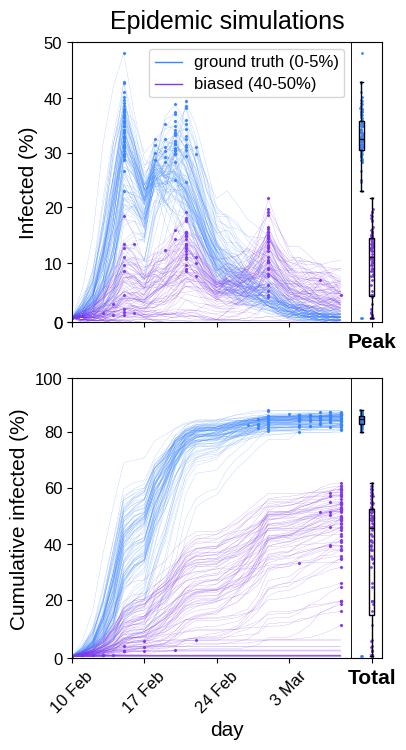

In [16]:
fig, axes = plt.subplots(figsize = (4,8), nrows = 2)

ax = axes[0]

sim_line = mlines.Line2D([], [], color=  config.COLOR_GT, label='', linewidth = 1)
simulations_infected_v1(ax, 
                        DICT_EMO, DICT_EMO_metrics, 
                        Date_range,
                        'Complete', 
                        config.COLOR_GT, 
                        box_x = 28)

simulations_infected_v1(ax, 
                        DICT_EMO, DICT_EMO_metrics,
                        Date_range,
                        k = ('Data_driven', Levels[3], 0, 'oracle_biased'), 
                        color = config.COLOR_BS, 
                        box_x = 29)

sim_line = mlines.Line2D([], [], color= config.COLOR_GT, label='', linewidth = 1)
ax.legend(handles=[sim_line], loc='upper right', bbox_to_anchor= (.9,1))

sim_line1 = mlines.Line2D([], [], color= config.COLOR_GT, label='ground truth (0-5%)', linewidth=1)
sim_line2 = mlines.Line2D([], [], color= config.COLOR_BS, label='biased (40-50%)', linewidth=1)
ax.legend(handles=[sim_line1, sim_line2], loc='upper right', title = '', bbox_to_anchor=(0.9, 1))

_yt = [int(N_users*p) for p in [0,0.11,0.21,0.31,0.41,0.51]]
print(_yt)
ax.set_yticks(_yt)
ax.set_yticklabels(_yt)
print(ax.get_yticklabels())


dict_ytl = {'t':  ax.get_yticks(), 
            'tl': (100*ax.get_yticks()/N_users).astype(int), 
            'rot': 0, 
            'size': 20} 
ax_visual_ticklabel(ax, dict_ytl, axis = 'y')
ax.set_ylabel('Infected (%)', size = 15)
ax.set_ylim(0,0.5)

ticks = ax.get_xticks()
labels = [''] * len(ticks)
labels[-1] = 'Peak'  # or format however you want
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(sorted(list(ax.get_yticks()) + [0]))

ax = axes[1]
sim_line = mlines.Line2D([], [], color= config.COLOR_GT, label='', linewidth = 1)
simulations_infected_v1(ax, 
                        DICT_EMO, DICT_EMO_metrics,  
                        Date_range,
                        'Complete', config.COLOR_GT, box_x = 28, em = 'final_size', viz = 'CI')

simulations_infected_v1(ax, 
                        DICT_EMO, DICT_EMO_metrics, 
                        Date_range,
                        k = ('Data_driven', Levels[3], 0, 'oracle_biased'), 
                        color = config.COLOR_BS, 
                        box_x = 29, 
                        viz= 'CI',
                        em = 'final_size')

sim_line = mlines.Line2D([], [], color=config.COLOR_GT, label='simulation', linewidth = 1)

ax.set_ylabel('count', size = 15)
ax.set_xlabel('day')
_yt = [int(N_users*p) for p in [0, 0.21,0.41,0.61,0.81,1]]
ax.set_yticks(_yt)
ax.set_yticklabels(_yt)
ax.set_ylim(0,1)

dict_ytl = {'t':  ax.get_yticks(), 
            'tl': (100*ax.get_yticks()/N_users).astype(int), 
            'rot': 0, 
            'size': 20} 
ax_visual_ticklabel(ax, dict_ytl, axis = 'y')
ax.set_ylabel('Cumulative infected (%)', size = 15)

#axis_add_tick(axes[0],0)
axes[0].set_title('Epidemic simulations', y =1.02)
for ax in axes:
    ax.tick_params(axis='x', rotation = 45)
    restyle_ax(ax)#, legend_font_size=10, legend_title_size=10, title_size = 15, tick_size = 10)
    print(ax.get_xticklabels())

ax = axes[0]
for label in ax.get_xticklabels():
    if label.get_text() == "Peak":
        label.set_fontweight("bold")
        label.set_rotation(0)
        label.set_fontsize(15)
    else:
        label.set_fontweight("normal")

ax = axes[1]
for label in ax.get_xticklabels():
    if label.get_text() == "Total":
        label.set_fontweight("bold")
        label.set_rotation(0)
        label.set_fontsize(15)
    else:
        label.set_fontweight("normal")



In [17]:
simul

NameError: name 'simul' is not defined

### Legends

In [ ]:
fig, ax = plt.subplots(figsize  = (4,2))

legend_elements = [
    Patch(facecolor= config.COLOR_GT, label = 'ground truth'),
    Patch(facecolor= 'none', label = '\nSparsity approach'),
    Patch(facecolor= config.COLOR_BS, label = 'Data driven'),
    Patch(facecolor= config.COLOR_RANDOM_SHUFFLING , label= 'Random shuffling'),
    Patch(facecolor= config.COLOR_RANDOM_UNIFORM , label='Random uniform')
]
ax.legend(handles = legend_elements,
          title = '',
          loc = 'center',
          #bbox_to_anchor=(0.5, 1.45),   # push legend above the figure
          ncol=1,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          title_fontsize = config.ax_legend_title_size,
          fontsize = config.ax_legend_font_size,
          framealpha=1,         # fully opaque
          facecolor= "white",    # white background
          edgecolor= "black")

restyle_ax(ax)
ax.axis('off')

plt.savefig(f'{FOLD_save}Figures/legend_sparsity_approaches.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

### Gap descriptive statistics

Input data is a trajectory record indicator with columns corresponding to the hours of the study period;

Each row is an individual sequence of record indicators; the sequence has two additional indicator columns:
- __id__: user-id to which the sequence belongs
- __weekstep-index__: the number of weeks by which the sequence is shifted with respect to the study-period

#### [data] Collection of sparse sequences and gap information

In [20]:
df = DICT_data['trajectory_record_indicator'].copy()
df['sequence_index'] = range(len(df))

Cols_index = ['id', 'weekstep_index', 'sequence_index']

#[a] sequences in the study period
df_seq_ss = df[df['weekstep_index'] == 0].set_index(Cols_index)
#remove sequences which have gaps larger than 1week
df_seq_ss = filter_sequences(df_seq_ss)
df_seq_ss = sort_df_rows(df_seq_ss)

#[b] sequences outside of the study period
df_seq_oss = df[df['weekstep_index'] != 0].set_index(Cols_index) 
df_seq_oss = filter_sequences(df_seq_oss)
df_seq_oss = sort_df_rows(df_seq_oss)

#[1] Collection of all sequences 
df_seq = pd.concat([df_seq_ss, df_seq_oss], axis=0)
df_seq = sort_df_rows(df_seq)

#COLLECTING THE SEQUENCES FOR ALL SCENARIOS
COLLECT_SEQUENCES_AND_GAPS = False

if COLLECT_SEQUENCES_AND_GAPS:
    
    #DATA-DRIVEN SEQUENCES 
    df_X_emp = df_seq.reset_index().set_index('sequence_index').drop(['id','weekstep_index'], axis=1)
    df_X_emp = sort_df_rows(df_X_emp)
    df_X_emp.to_csv('Data_experiments/Tables/sequences_data_driven.csv')
    df_X_emp.columns = pd.to_datetime(df_X_emp.columns)   
    df_gaps_emp = gen_gaps_df(df_X_emp)
    df_gaps_emp.to_csv('Data_experiments/Tables/gaps_data_driven.csv')
    
    #RANDOM SHUFFLING SEQUENCES (shuffle the gaps keeping their durations)
    df_X_random_keepdurations = df_X_emp.apply(lambda row: pd.Series(shuffle_gaps_keep_durations(row.values)), axis=1)
    df_X_random_keepdurations.columns = df_X_emp.columns
    df_X_random_keepdurations.to_csv('Data_experiments/Tables/sequences_random_shuffling.csv')
    df_gaps_random_kd = gen_gaps_df(df_X_random_keepdurations)
    df_gaps_random_kd.to_csv('Data_experiments/Tables/gaps_random_shuffling.csv')
    
    #RANDOM UNIFORM SEQUENCES (shuffle the entries at the hour-level)
    X_random = np.copy(df_X_emp.values)
    np.apply_along_axis(np.random.shuffle, axis=1, arr=X_random)
    df_X_random = pd.DataFrame(X_random,
                               index = df_X_emp.index, 
                               columns = df_X_emp.columns)
    df_X_random.to_csv('Data_experiments/Tables/sequences_random_uniform.csv')
    df_gaps_random = gen_gaps_df(df_X_random)
    df_gaps_random.to_csv('Data_experiments/Tables/gaps_random_uniform.csv')

In [21]:
df_gaps_emp        = pd.read_csv('Data_experiments/Tables/gaps_data_driven.csv')
df_gaps_random_kd  = pd.read_csv('Data_experiments/Tables/gaps_random_shuffling.csv')
df_gaps_random     = pd.read_csv('Data_experiments/Tables/gaps_random_uniform.csv')

In [22]:
df_gaps_emp.shape, df_gaps_random_kd.shape

((298739, 5), (298208, 5))

In [23]:
df_gaps_emp.head(2)

,sequence_index,gaps,start,gap_duration_hours,start_hour
0,5788,"(Timestamp('2014-02-17 20:00:00'), Timestamp('...",2014-02-17 20:00:00,1.0,20
1,5519,"(Timestamp('2014-03-05 19:00:00'), Timestamp('...",2014-03-05 19:00:00,1.0,19


In [24]:
df_gaps_random_kd.head(2)

,sequence_index,gaps,start,gap_duration_hours,start_hour
0,5788,"(Timestamp('2014-02-26 05:00:00'), Timestamp('...",2014-02-26 05:00:00,1.0,5
1,5519,"(Timestamp('2014-02-10 06:00:00'), Timestamp('...",2014-02-10 06:00:00,1.0,6


#### [Supplementary Figure 2] Instance of sparsification

In [25]:
#[1] import sequence indicator
df_seq = pd.read_csv('Data_experiments/df_trajectory_record_indicator.csv', index_col = 0).set_index(['id','weekstep_index'])
#remove sequences which have gaps larger than 1week
df_seq = filter_sequences(df_seq)

#[2] select the complete users
df_seq_w0 = df_seq[df_seq.index.get_level_values("weekstep_index") == 0]
df_seq_complete = df_seq_w0[df_seq_w0.mean(axis=1) >= 0.95]

df_seq = df_seq.droplevel('weekstep_index')
df_seq_complete = df_seq_complete.droplevel('weekstep_index')

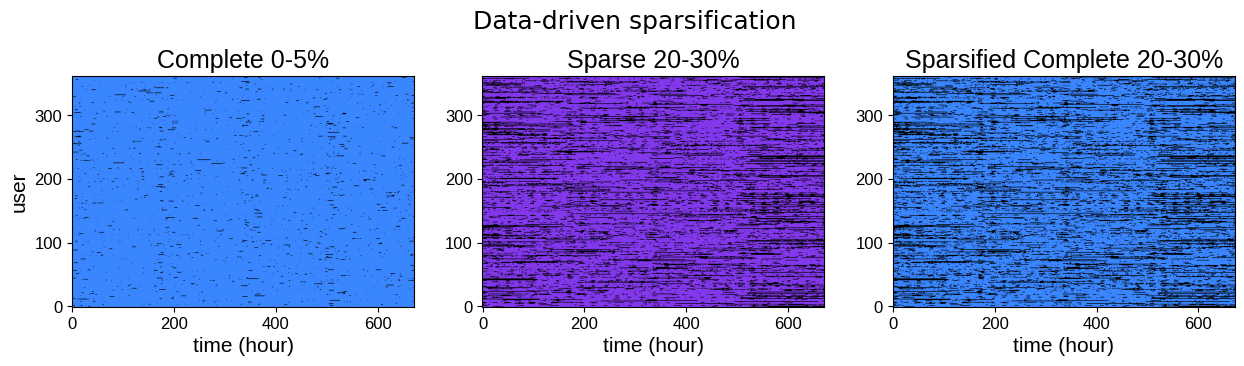

In [26]:
Levels = config.Levels

level = Levels[1]
mask_l = gen_mask(level, 
                  df_seq,
                  df_seq_complete)

mask_l = mask_l.loc[df_seq_complete.index]
df_seq_complete_sparsified = mask_l*df_seq_complete

fig, axes = plt.subplots(figsize = (15,3), ncols = 3)

HRIs = [df_seq_complete.values,
         mask_l.values,
         df_seq_complete_sparsified.values]

Colors = [config.COLOR_GT, 
          config.COLOR_BS, 
          config.COLOR_GT]

Titles = ['Complete 0-5%', 
          f'Sparse {config.DICT_rename_levels[level]}%', 
          f'Sparsified Complete {config.DICT_rename_levels[level]}%']

for ax, hri, color, title in zip(axes, HRIs, Colors, Titles):
    visual_imshow(ax, hri, ['black', color])
    ax.set_xlabel('time (hour)')
    axes[0].set_ylabel('user')
    ax.set_title(title)
    restyle_ax(ax)
plt.suptitle('Data-driven sparsification', size = config.ax_title_size, y= 1.1 )

plt.savefig(f'{FOLD_save}Figures/supp_instance_sparsification.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Supplementary Table 3] Count of trajectories by sparsity level

In [27]:
def add_feature_qrange(df_X):
    '''
    df_X : dataframe with 
        rows: user id
        columns: hours of the study period
    '''
    Q = (df_X ==0).sum(axis=1)/df_X.shape[1]
    Q_ranges =  np.concatenate([np.array([0,.05]), np.arange(0.1,1.1,0.1)])
    df_X['q_range'] = np.digitize(Q, Q_ranges)

_seq = df_seq_ss.copy()
add_feature_qrange(_seq)
df_seq_ss_count = _seq.groupby('q_range').size()
df_seq_ss_count

_seq = df_seq.copy()
add_feature_qrange(_seq)
df_seq_count = _seq.groupby('q_range').size()
df_seq_count

df_seq_count = pd.concat([df_seq_ss_count, df_seq_count], axis=1).fillna(0).astype(int)
df_seq_count.columns = ['8 Feb 2014 - 7 Mar 2014 ', '2 Feb 2014 - 2 Feb 2015']
df_seq_count = df_seq_count.rename(index={ 'q_range': 'missing hours (%)'})

df_seq_count.index = ['0-5',
                      '5-10',
                      '10-20',
                      '20-30',
                      '30-40',
                      '40-50',
                      '50-60',
                      '60-70',
                      '70-80',
                      '80-90',
                      '90-100']

df_seq_count.index.name = 'missing hours (%)'
df_seq_count.T

missing hours (%),0-5,5-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80,80-90,90-100
8 Feb 2014 - 7 Mar 2014,363,90,63,36,16,12,6,5,2,1,0
2 Feb 2014 - 2 Feb 2015,11327,3972,3482,1873,1159,568,326,242,169,82,37


In [28]:
latex_str = df_seq_count.T.to_latex(
    escape=False,
    index=True)

with open("Data_experiments/Tables/sequence_count_missing_hours.tex", "w") as f:
    f.write(latex_str)

#### [Supplementary Figure 3] Selection of sparse trajectories for sparsification

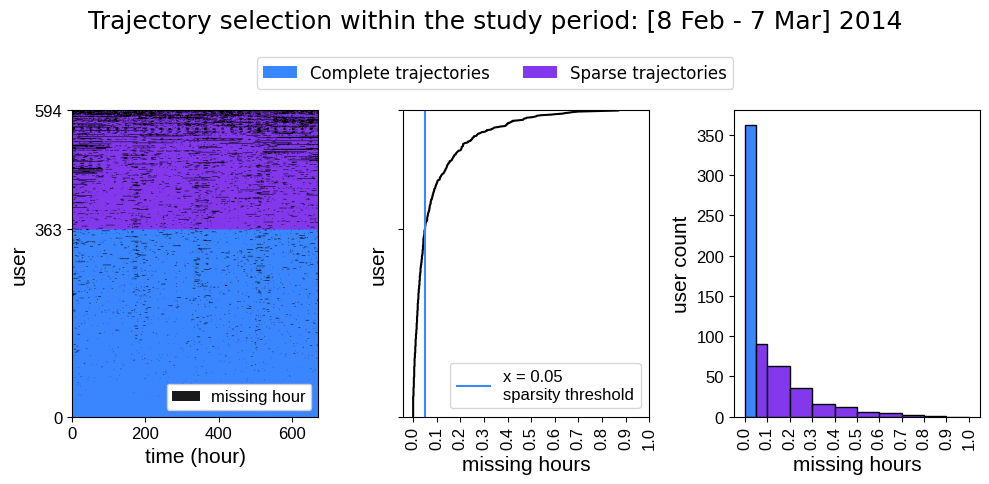

In [29]:
def ax_visual_sparseseq(ax, Recs_ind, Colors):
    '''
    Recs_ind : record indicators 
    List_ts  : timestamps sequence
    '''
    
    visual_imshow(ax, 
                  Recs_ind, 
                  Colors)
       
    ax.tick_params(axis = 'both', 
                   rotation = 360, 
                   labelsize = 20)

fig, axes = plt.subplots(figsize = (10,4), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios':[2,2,2]})

ax = axes[0]
#record indicator matrix
RIM = df_seq_ss.values
#sparsity
q = RIM.sum(axis=1)/RIM.shape[1]
ax.set_xlabel('time (hour)')
ax.set_ylabel('user')

legend_elements = [
    Patch(facecolor=config.COLOR_GAPS, edgecolor='none', label='missing hour')
]
leg = ax.legend(handles=legend_elements, loc="lower right", frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(1.0) 



#change RIM
RIM[q>0.95,:] *=2

ax_visual_sparseseq(ax, 
                    RIM, 
                    Colors = ['black', 
                              config.COLOR_BS, 
                              config.COLOR_GT])

ax = axes[1]
ax.plot(1-q, range(len(q)), color = 'black')#, q)
_xticks = np.round(np.arange(0,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)
ax.set_xlabel('missing hours')
ax.set_ylabel('user')
ax.axvline(0.05, color = config.COLOR_GT, label = 'x = 0.05 \nsparsity threshold')
ax.legend(loc= 'lower right', fontsize = config.ax_legend_font_size)

for ax in axes[:2]:
    _xticks =[0,363, len(RIM)]
    ax.set_yticks(_xticks)
    ax.set_yticklabels(_xticks)#, rotation = 90)

    ax.set_ylim(0,len(df_seq_ss))
    restyle_ax(ax)

remove_axis_ticktext(axes[1], axis = 'y')

    

ax = axes[2]
Bins = np.arange(.1,1.1,.1)
Bins = [0,0.05] + list(Bins)
Counts, Bins = np.histogram(1-q, 
                            bins = Bins)

X = (Bins[:-1] + Bins[1:]) / 2

ax.bar(X, 
       Counts, 
       width = [0.05]*2 + [0.1]*9,
       color = [config.COLOR_GT] + [config.COLOR_BS]*10,
       edgecolor = 'black')

_xticks = np.round(np.arange(0,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)

ax.set_xlabel('missing hours')
ax.set_ylabel('user count')
restyle_ax(ax)

plt.tight_layout()
plt.suptitle('Trajectory selection within the study period: [8 Feb - 7 Mar] 2014', y = 1.2, size = config.ax_title_size)


from matplotlib.patches import Patch

h1 = Patch(facecolor=config.COLOR_GT, edgecolor='none', label='Complete trajectories')
h2 = Patch(facecolor=config.COLOR_BS, edgecolor='none', label='Sparse trajectories')

fig.legend(
    handles=[h1, h2],
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    fontsize=config.ax_legend_font_size
)

plt.savefig(f'{FOLD_save}Figures/supp_trajectory_count_study_period.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

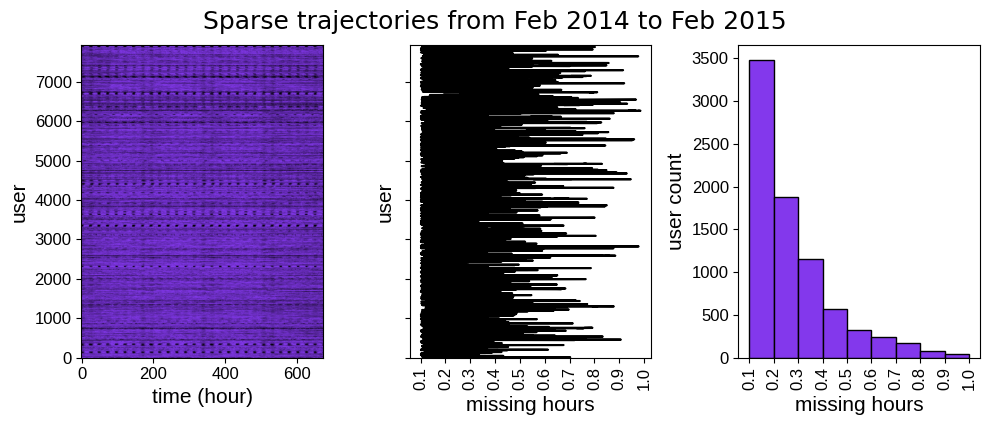

In [30]:
fig, axes = plt.subplots(figsize = (10,4), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios':[2,2,2]})

ax = axes[0]
#record indicator matrix
RIM = df_seq.values
#sparsity
q = RIM.sum(axis=1)/RIM.shape[1]
ax.set_xlabel('time (hour)')
ax.set_ylabel('user')

#change RIM
RIM = RIM[q<0.9,:] 
q= q[q<0.9]

ax_visual_sparseseq(ax, 
                    RIM, 
                    Colors = ['black', 
                              config.COLOR_BS])

ax = axes[1]
ax.plot(1-q, range(len(q)), color = 'black')#, q)
_xticks = np.round(np.arange(.1,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)
ax.set_xlabel('missing hours')
ax.set_ylabel('user')
remove_axis_ticktext(ax, axis = 'y')


for ax in axes[:2]:
    ax.set_ylim(0,len(RIM))
    restyle_ax(ax)

ax = axes[2]
Bins = np.arange(.1,1.1,.1)
#Bins = [0,0.05] + list(Bins)

Counts, Bins = np.histogram(1-q, 
                            bins = Bins)

X = (Bins[:-1] + Bins[1:]) / 2

ax.bar(X, 
       Counts, 
       width = [0.1]*9,
       color = config.COLOR_BS,
       edgecolor = 'black')

_xticks = np.round(np.arange(.1,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)

ax.set_xlabel('missing hours')
ax.set_ylabel('user count')
restyle_ax(ax)

plt.tight_layout()
plt.suptitle('Sparse trajectories from Feb 2014 to Feb 2015', y = 1.05, size = config.ax_title_size)

plt.savefig(f'{FOLD_save}Figures/supp_trajectory_count_total_range.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [data for Figure 2b] Descriptive statistics of missingness

- count of gap durations for each range of missing hours
    - df_gap_count.csv 
- sequence-level entropies
    - df_sequence_entropies.csv  

In [31]:
#Convert to the range of missing hours in (%)
dict_q_mh = { 1: '0-10',
              2: '10-20',
              3: '20-30',
              4: '30-40',
              5: '40-50',
              6: '50-60',
              7: '60-70',
              8: '70-80',
              9: '80-90',
              10: '90-100'}

def add_feature_qrange(df_X):
    '''
    df_X : dataframe with 
        rows: user id
        columns: hours of the study period
    '''
    Q = (df_X ==0).sum(axis=1)/df_X.shape[1]
    Q_ranges =  np.arange(0,1.1,0.1)
    df_X['q_range'] = np.digitize(Q, Q_ranges)
    
#random shuffling is equal to data-driven; so it is not computed
_types = ['data_driven', 'random_uniform']
_types_names = ['Data driven', 'Random uniform']

COMPUTE_GAP_COUNT = True

DF_gap_count = []
if COMPUTE_GAP_COUNT:

    for _type, _type_name in zip(_types, _types_names):
    
        #[1] record indicator matrix
        df_X = pd.read_csv(f'Data_experiments/Tables/sequences_{_type}.csv', index_col = 0)
        
        #label each sequence by the range of missing hours
        add_feature_qrange(df_X)
        
        df_X['missing_hours'] = df_X['q_range'].replace(dict_q_mh)
        
        #[2] data-frame of gaps
        df_gaps = pd.read_csv(f'Data_experiments/Tables/gaps_{_type}.csv', index_col=0)
        df_gaps['missing_hours'] = df_gaps.index.map(df_X['missing_hours'])
        
        #COUNT THE GAPS FOR EACH RANGE OF MISSING HOURS 
        df_gap_count = (
            df_gaps
            .groupby(['missing_hours', 'gap_duration_hours'])
            .size()
            .reset_index())
        
        df_gap_count = df_gap_count.rename(columns = {0: 'count'})
        
        df_gap_count['sparsity'] = _type_name
        DF_gap_count.append(df_gap_count)
    
    df_gap_count = pd.concat(DF_gap_count, axis=0)
    df_gap_count.to_csv('Data_experiments/Tables/df_gap_count.csv')

COMPUTE_ENTROPIES = True

DF_entropies = []

if COMPUTE_ENTROPIES:

    for _type, _type_name in zip(_types, _types_names):
    
        #[1] record indicator matrix
        df_X = pd.read_csv(f'Data_experiments/Tables/sequences_{_type}.csv', index_col = 0)
        
        #label each sequence by the range of missing hours
        add_feature_qrange(df_X)
        df_X['missing_hours'] = df_X['q_range'].replace(dict_q_mh)
        
        #[2] data-frame of gaps
        df_gaps = pd.read_csv(f'Data_experiments/Tables/gaps_{_type}.csv', index_col=0)
        
        #[3] compute the entropy for each individual sequence of records
        df_entropy = df_gaps.groupby(df_gaps.index).apply(lambda x : compute_entropy(x), 
                                                          include_groups= False)
        
        df_entropy = pd.DataFrame(df_entropy).rename(columns = {0:_type_name})
        if _type =='data_driven':
            df_entropy['missing_hours'] = df_entropy.index.map(df_X['missing_hours'])
    
        DF_entropies.append(df_entropy)
        
    DF_entropies = pd.concat(DF_entropies,axis=1)
    DF_entropies = DF_entropies.set_index('missing_hours', append = True)
    
    DF_entropies.to_csv('Data_experiments/Tables/df_sequence_entropies.csv')


#### [Figure 2b] Descriptive statistics of missingness for 40-50% sparsity

In [32]:
df_gap_count = pd.read_csv('Data_experiments/Tables/df_gap_count.csv', index_col = 0)
df_gap_count.head(2)

,missing_hours,gap_duration_hours,count,sparsity
0,0-10,1.0,37250,Data driven
1,0-10,2.0,16181,Data driven


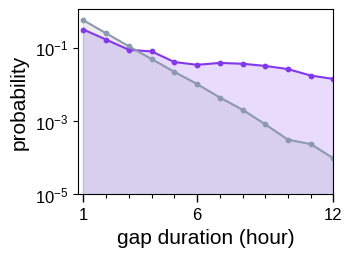

In [33]:
fig, ax = plt.subplots(figsize = (3.3,2.4))

level_missing_hours = '40-50'
panel_gap_distribution(ax, 
                       df_gap_count,
                       level= level_missing_hours,
                       fill_alpha = 0.18,
                       hours_select = range(1,13), 
                       ax_ticks = True)

ax.set_xlabel('gap duration (hour)')
ax.set_ylabel('probability')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_pmf_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [34]:
df_sequence_entropies = pd.read_csv('Data_experiments/Tables/df_sequence_entropies.csv', index_col = 0)
df_sequence_entropies.head(2)

,missing_hours,Data driven,Random uniform
sequence_index,,,
0,0-10,0.636514,0.0
1,0-10,0.000000,0.0


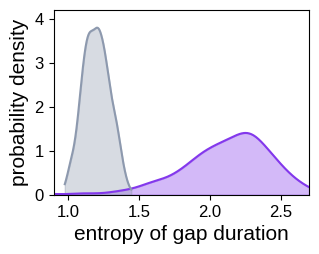

In [35]:
fig, ax = plt.subplots(figsize = (3.3,2.4))

panel_sequence_entropies(ax,
                         df_sequence_entropies,
                         level_missing_hours = '40-50',
                         alpha = 0.35)
ax.set_xlabel('entropy of gap duration')
ax.set_ylabel('probability density')

#ax.set_title(f'{level_missing_hours}% missing hours')


ax.set_ylim(0,4.2)
ax.set_xlim(.9,2.7)
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_entropy_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Supplementary Figure 4] Gap statistics for all sparsity ranges

/tmp/ipykernel_217947/722690385.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_217947/722690385.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_217947/722690385.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_217947/722690385.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_217947/722690385.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)


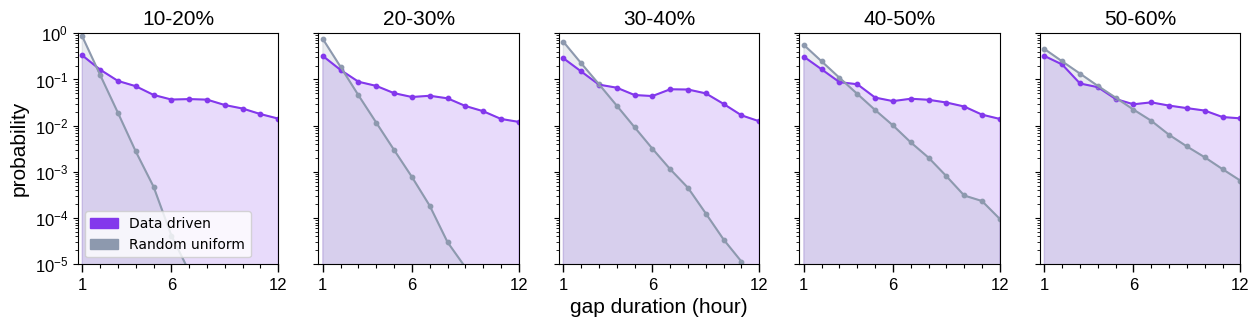

In [36]:
fig, axes = plt.subplots(figsize = (15,3), ncols = 5)

for ax, level_missing_hours in zip(axes, config.Levels_str):
    panel_gap_distribution(ax, 
                           df_gap_count,
                           level= level_missing_hours,
                           fill_alpha = 0.18,
                           hours_select = range(1,13), 
                           ax_ticks = True)
    
    ax.set_ylim(0,1)
    ax.set_title(level_missing_hours + '%')
    restyle_ax(ax, title_size = config.ax_label_size)

axes[2].set_xlabel('gap duration (hour)')
axes[0].set_ylabel('probability')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')

ax = axes[0]
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Data driven',
                                'Random uniform'],
                    'colors': [config.COLOR_BS, config.COLOR_RANDOM_UNIFORM], 
                    'title': '', 
                    'loc': 'lower left', 
                    'fontsize':10,
                    'title_fontsize':10})
ax_visual_legend(ax, DICT_legend)

plt.savefig(f'{FOLD_save}Figures/supp_gap_pdf.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

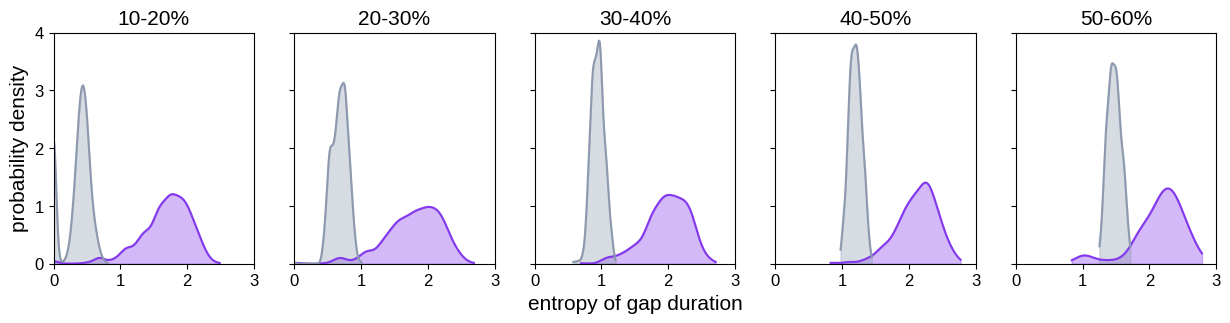

In [37]:
fig, axes = plt.subplots(figsize = (15,3), ncols = 5)

for ax, level_missing_hours in zip(axes, config.Levels_str):
    
    panel_sequence_entropies(ax,
                         df_sequence_entropies,
                         level_missing_hours = level_missing_hours,
                         alpha = 0.35)    
    
    ax.set_title(level_missing_hours + '%')
    ax.set_xlim(0,3)
    ax.set_ylim(0,4)
    restyle_ax(ax, title_size = config.ax_label_size)

axes[2].set_xlabel('entropy of gap duration')
axes[0].set_ylabel('probability density')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')

plt.savefig(f'{FOLD_save}Figures/supp_gap_entropy.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)


### Contact metrics and relationships with missingness

In order to compute the probability of contacts, given a weekeperiod (weekend or weekday), 

we normalize the number of detected contacts over the hour of the day

In [ ]:
#CONTACT METRICS
df = DICT_data['user_contact_count']
df['missing_users_perc'] = (config.N_users - df['count_users'])/config.N_users
df.head(2)

#### [data for Figure 2c] Count of detected contacts and missing users over hourofday during each weekperiod

In [ ]:
COMPUTE_CONTACT_SHARE = False
if COMPUTE_CONTACT_SHARE:
    df_contact_share = [] 
    for s in config.List_ss_rename:
        for wp in ['weekday', 'weekend']:
            for l in config.Levels:
                for N_si in range(50):
                    #compute the contact share for each sparsity iteration
                    df_i = df[df['iter_sparsity'] == N_si]
                    _cs = contact_share(df, 
                                        s = s, 
                                        wp = wp, 
                                        l  = l)
                    
                    _cs['iter_sparsity'] = N_si
                    
                df_contact_share.append(_cs)
                
    df_contact_share = pd.concat(df_contact_share, axis = 0)
    df_contact_share.to_csv(f'{FOLD_save}Tables/contact_shares_sparsity-iteration.csv')

#Given a weekeperiod; for each hourofday compute the contact share averaged over each 50 missingness realizations
df_contact_share = pd.read_csv(f'{FOLD_save}Tables/contact_shares_sparsity-iteration.csv', 
                               index_col = 0)
df_contact_share.head(2)

In [ ]:
COMPUTE_avg_missing_user = False

if COMPUTE_avg_missing_user:
    
    df_avg_missing_user = [] 
    for s in config.List_ss_rename:
        for wp in ['weekday', 'weekend']:
            for l in config.Levels:
                for N_si in range(50):
                    #compute the contact share for each sparsity iteration
                    df_i = df[df['iter_sparsity'] == N_si]
                    _cs = stats_missing_users(df, 
                                              s = s, 
                                                wp = wp, 
                                        l  = l)
                    
                    _cs['iter_sparsity'] = N_si
                    
                df_avg_missing_user.append(_cs)
                
    df_avg_missing_user = pd.concat(df_avg_missing_user, 
                                 axis = 0)
    df_avg_missing_user.to_csv(f'{FOLD_save}Tables/avg_missing_users_sparsity-iteration.csv')

df_avg_missing_user = pd.read_csv(f'{FOLD_save}Tables/avg_missing_users_sparsity-iteration.csv', index_col = 0)
df_avg_missing_user.head(2)

In [ ]:
df_avg_missing_user['missing_users_perc'].describe()

#### [Figure 2c] prob. of missingness and contact

In [ ]:
Cols_select = ['hourofday', 
               'sparsity', 
               'sparsity_level', 
               'weekperiod']

contact_metric = 'missing_users_perc'
df_csa = df_avg_missing_user.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()

fig, ax = plt.subplots(figsize = (3.3,2.4))
l = config.Levels[3]
panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
ax.set_ylim(0.3,0.6)
ax.set_xlim(0, 23)
legend_weekend_weekday(ax, 
                       loc = 'upper left')

ax.set_ylabel("prob. missingness (%)")
ax.set_xlabel('')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_prob_missingness_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

Cols_select = ['hourofday', 
               'sparsity', 
               'sparsity_level', 
               'weekperiod']

#averaged feature (contact share or absolute number of contacts)
contact_metric = 'contact_share'
df_csa = df_contact_share.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()

fig, ax = plt.subplots(figsize = (3.3,2.4))
l = config.Levels[3]
panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
ax.set_ylim(0, 0.11)
ax.set_xlim(0, 23)
ax.set_xlabel('')

#legend_weekend_weekday(ax, 
#                       loc = 'upper right')

ax.set_ylabel("prob. contact (%)")
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_prob_contact_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Supplementary Figure 2c] prob. of missingness and contact for all sparsity ranges

In [ ]:
fig, Axes = plt.subplots(figsize = (15,6), ncols = 5, nrows = 2)

axes = Axes[0,:]
contact_metric = 'missing_users_perc'
df_csa = df_avg_missing_user.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()

for l,ax in zip(config.Levels, axes):
    panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
    #ax.set_yscale('log')
    ax.set_ylim(0, 0.7)
    _yticks= np.round(np.arange(0,.8,.2),2)
    ax.set_yticks(_yticks)
    ax.set_yticklabels(_yticks)
    ax.set_title(config.DICT_rename_levels[l] + '%')
    restyle_ax(ax)

for ax in axes:
    ax.set_xlabel('')
for ax in axes[1:]:
    ax.set_ylabel('')
    
legend_weekend_weekday(axes[0], 
                       loc = 'upper right')
axes[0].set_ylabel("prob. missingness (%)")


axes = Axes[1,:]

contact_metric = 'contact_share'
df_csa = df_contact_share.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()
for l,ax in zip(config.Levels, axes):
    panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
    ax.set_ylim(0, 0.12)
    ax.set_xlim(0, 23)

    ax.set_title(config.DICT_rename_levels[l] + '%')
    restyle_ax(ax)

for ax in axes:
    ax.set_xlabel('')
for ax in axes[1:]:
    ax.set_ylabel('')
 
axes[0].set_ylabel("prob. contact (%)")

plt.tight_layout()

plt.savefig(f'{FOLD_save}Figures/supp_gap_stat_prob_missingness_contact.png',
            format = "png", 
            bbox_inches = 'tight', 
            dpi = 300)

#### [Figure 2d] Correlation between detected contacts and fraction of missing users

In [ ]:
fig, axes = plt.subplots(figsize = (8.3, 3), ncols=3)

panels_missing_users_detected_contacts(axes, 
                                       df, 
                                       config.Levels[3])

ax= axes[0]
ax_inset = ax.inset_axes([0.3, 0.9, 0.55, 0.05])
ax_colorbar_inset(ax_inset)

axes[0].set_xlim(.2,.8)
axes[1].set_xlim(.3,.6)
axes[2].set_xlim(.3,.6)
for ax in axes:
    set_percent_xticks(ax, decimals = 0)
    restyle_ax(ax, title_size = config.ax_label_size)

plt.savefig(f'{FOLD_save}Figures/gap_correlation_missingness_contacts_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Supplementary Figure 2d] Correlation between detected contacts and fraction of missing users for all sparsity ranges

In [ ]:
fig, Axes = plt.subplots(figsize = (8.3, 12), 
                         ncols=3, nrows = 5)

for i,l in enumerate(config.Levels):

    axes= Axes[i]
    panels_missing_users_detected_contacts(axes, 
                                           df, 
                                           l)

    
    for j, ax in enumerate(axes):
        ax.set_xlabel('')
        ax.set_ylabel('')
        if i != 0:
            ax.set_title('')
        #if i != 4:
            #remove_axis_ticktext(ax, axis ='x')
        if j != 0:
            remove_axis_ticktext(ax, axis= 'y')
        else:
            ax.set_ylabel(config.DICT_rename_levels[l] + '%')
        restyle_ax(ax, title_size=config.ax_label_size)

ax= Axes[0,0]
ax_inset = ax.inset_axes([0.15, 0.35, 0.55, 0.05])
ax_colorbar_inset(ax_inset)

Axes[0,0].text(
    1, 1.2,
    'Sparsification approach',
    size=config.ax_title_size,
    rotation=0,
    transform=Axes[0,0].transAxes
)

Axes[2,0].text(-.1,.5, 'detected contacts', size = config.ax_title_size, rotation = 90)
Axes[4,1].set_xlabel('missing users (%)')

plt.savefig(f'{FOLD_save}Figures/supp_correlation_missingness_contacts.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Supplementary Table] Correlation between detected contacts and fraction of missing users

In [ ]:
def compute_corrs(df_merged):

    _LS = config.List_ss_rename
    x_metric= 'missing_users_perc'
    
    df_corrs = []
    for s in _LS:  
        df_s = df_merged[df_merged['sparsity'] == s]
        dict_level_df_s = subset_df_feature(df_s, 'sparsity_level').copy()
        for l in config.Levels:
            df_sl = dict_level_df_s[str(l)].copy()
            R2 = rsq(df_sl, 
                     x_metric, 
                     'count_contacts')
            rec= [s,l,R2]
            df_corrs.append(rec)
    df_corrs = pd.DataFrame(df_corrs,  columns = ['sparsity','sparsity_level','rho'])
    return df_corrs
    
df_corrs = compute_corrs(df)
df_corrs = df_corrs.pivot(index=  'sparsity_level', columns = 'sparsity', values = 'rho').round(2)
df_corrs.index.name = 'missing hours (%)'
df_corrs.index = ['10-20', '20-30', '30-40','40-50','50-60']
df_corrs

latex_str = df_corrs.to_latex(
    escape=False,
    index=True
)

with open("Data_experiments/Tables/correlation_detected_contacts_missing_users.tex", "w") as f:
    f.write(latex_str)

#### [Supplementary Figure 6] Variation of contacts and stop duration

- stop_time_overall:
    - compute the total individual stop duration as the cumulative time spent in stops over the study period
    - visualize it for a specific sparsity iteration

In [ ]:
fig, axes = plt.subplots(figsize = (12,3),ncols = 5)

#select first sparsity iteration
N_si = 0

Colors = [config.COLOR_BS, config.COLOR_RANDOM_SHUFFLING, config.COLOR_RANDOM_UNIFORM]
for s, color in zip(['Data_driven', 'Random_keepdurations', 'Random_uniform'], Colors):
    
    collection_stop_stats = [DICT_stop_stats['Complete']['stop_time_overall']]
    collection_stop_stats += [DICT_stop_stats[(s,l,N_si)]['stop_time_overall'] for l in config.Levels]
    df_stop_stats = pd.concat(collection_stop_stats, axis=1)
    df_stop_stats.columns = ['Complete'] + config.Levels
    
    for ax, l in zip(axes, config.Levels):
        ax.scatter(df_stop_stats['Complete'], 
                   df_stop_stats[l], 
                   s = .5, 
                   color = color)
        ax.plot([0, 30], [0, 30], color='black', linewidth = .2)
        
        ax.set_title(config.DICT_rename_levels[l] + '%')
    
    
for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')
    
axes[2].set_xlabel('ground truth duration (day)')
axes[0].set_ylabel('biased duration (day)')
#plt.suptitle('Individual total time in stops over [10 Feb - 8 Mar]', x = 0.6, y = 1.10, size = 20)
for ax in axes:
    ax.set_ylim(8,26)
    ax.set_xlim(14,28)
    restyle_ax(ax)

legend_elements = [
    Patch(facecolor= config.COLOR_BS, label = 'Data driven'),
    Patch(facecolor= config.COLOR_RANDOM_SHUFFLING , label= 'Random shuffling'),
    Patch(facecolor= config.COLOR_RANDOM_UNIFORM , label='Random uniform')
]
axes[2].legend(handles = legend_elements,
          title = 'Sparsity approach',
          loc = 'upper center',
          bbox_to_anchor=(0.5, 1.45),   # push legend above the figure
          ncol=3,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          title_fontsize = config.ax_legend_title_size,
          fontsize = config.ax_legend_font_size,
          framealpha=1,         # fully opaque
          facecolor= "white",    # white background
          edgecolor= "black")     # optional: black border

plt.savefig(f'{FOLD_save}Figures/supp_stop_total_duration.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
Levels = config.Levels
df_contact_counts = DICT_data['contact_count_change-duration'].copy()
df_contact_counts = df_contact_counts.reset_index()
cols_levels = [str(l) for l in Levels]
df_contact_counts['detected'] = df_contact_counts['index'] != 'eliminated'
df_counts_detected = df_contact_counts[df_contact_counts['detected']]
cols_levels = [str(l) for l in Levels]

N_si = 0
df_cn = df_counts_detected[df_counts_detected['N_si'] == N_si]

# columns to normalize
cols_levels = [str(l) for l in Levels]

# group-sum per 's'
group_sums = df_cn.groupby('s')[cols_levels].transform('sum')

# normalized version
df_cn_norm = df_cn.copy()
df_cn_norm[cols_levels] = df_cn[cols_levels] / group_sums
df_cn_norm = df_cn_norm.set_index(['s','index'])

fig, axes = plt.subplots(figsize = (12,3), ncols = 3)


for ax, s in zip(axes, 
                 config.List_ss_rename):
    
    a1,a2,a3 = (df_cn_norm.loc[s,_c][cols_levels] for _c in ['reduced', 'unchanged','increased'])
    x = np.arange(len(a1))

    ax.bar(x, a1,               width = 1, color = 'red', edgecolor = 'black')
    ax.bar(x, a2, bottom=a1,    width = 1, color = 'gray' , edgecolor = 'black')
    ax.bar(x, a3, bottom=a1+a2, width = 1, color = 'green'  , edgecolor = 'black')

    ax.set_title(s)
    ax.set_xlim(-.5,4.5)
    ax.set_ylim(0,1)

axes[1].set_xlabel('missing hours (%)')
axes[0].set_ylabel('fraction')
for ax in axes:
    DICT_xtl = gen_DICT_ax_visual('label_ticks')
    X = range(5)
    DICT_xtl['t']  = list(X)
    xtl = ['10-20', '20-30', '30-40', '40-50', '50-60']
    DICT_xtl['tl'] = xtl
    DICT_xtl['rot'] = 45
    ax_visual_ticklabel(ax, DICT_xtl, axis='x')
    restyle_ax(ax)


legend_elements = [
    Patch(facecolor= 'green', label = 'increased'),
    Patch(facecolor= 'gray',  label=  'unchanged'),
    Patch(facecolor= 'red',   label=  'decreased')
]
axes[1].legend(handles = legend_elements,
          title = 'Change in daily contact duration from ground truth',
          loc = 'upper center',
          bbox_to_anchor=(0.5, 1.45),   # push legend above the figure
          ncol=3,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          title_fontsize = config.ax_legend_title_size,
          fontsize = config.ax_legend_font_size,
          framealpha=1,         # fully opaque
          facecolor= "white",    # white background
          edgecolor= "black")     # optional: black border

plt.savefig(f'{FOLD_save}Figures/supp_change_daily_contact_duration.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)


#### [Supplementary Figure] - variation of contact patterns - sparsification

- number of detected contacts over the study period
- average daily contact duration
- average daily reproductive number over the study period

In [ ]:
#INPUT DATA
#number of contacts
df_nc = DICT_data['supp_contact_count_sparsification']
#contact duration
df_cd = DICT_data['supp_contact_average_duration_sparsification']
#reproductive number
df_R0 = DICT_data['supp_contact_average_R0_sparsification']

#COMPUTE_STATS
df_nc_stats = metric_stats(df_nc, 
                           'count', 
                           df_cols = ['sparsity', 'sparsity_level'])

df_cd_stats = metric_stats(df_cd, 
                           'avg_duration', 
                            df_cols = ['sparsity', 'sparsity_level'])

df_R0_stats = metric_stats(df_R0, 
                           'avg_R0', 
                            df_cols = ['sparsity', 'sparsity_level'])

fig, axes = plt.subplots(figsize = (12,4), ncols = 3)

LIST_stats = [df_nc_stats, df_cd_stats, df_R0_stats]
LIST_vars  = ['count','avg_duration', 'avg_R0']
LIST_ylabels = ['#detected contacts', 'avg. daily duration (minutes)', 'average $R_0$']

X = np.arange(1,6)*6

for ax, df_stat, var, ylabel in zip(axes, LIST_stats, LIST_vars, LIST_ylabels):

    visual_metric(ax, 
                  df_stat.set_index(['sparsity','sparsity_level']), 
                  var, 
                  config.List_ss_rename, 
                  X, 
                  col_gt= 'ground truth',
                  visual_mean = False,
                  visual_std_groundtruth = False,
                  color_mean_std = 'black',
                  bar_errorbar_gt= False,
                  bar_as_median = True)
    
    ax.set_ylabel(ylabel)
    axes[1].set_xlabel('missing hours (%)')
    restyle_ax(ax)

plt.tight_layout()


legend_elements = [
    Patch(facecolor= config.COLOR_GT, label = 'ground truth'),
    Patch(facecolor= config.COLOR_BS, label = 'Data driven'),
    Patch(facecolor= config.COLOR_RANDOM_SHUFFLING , label= 'Random shuffling'),
    Patch(facecolor= config.COLOR_RANDOM_UNIFORM , label='Random uniform')
]
axes[1].legend(handles = legend_elements,
          title = 'Sparsity approach',
          loc = 'upper center',
          bbox_to_anchor=(0.5, 1.3),   # push legend above the figure
          ncol=4,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          title_fontsize = config.ax_legend_title_size,
          fontsize = config.ax_legend_font_size,
          framealpha=1,         # fully opaque
          facecolor= "white",    # white background
          edgecolor= "black")     # optional: black border

plt.savefig(f'{FOLD_save}Figures/supp_contact_changes.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Supplementary Figure] - variation of contact patterns - biased and corrected contacts

Comparison is performed under the 'Data driven' sparsification approach
- average daily contact duration
- average daily reproductive number over the study period

Number of detected contacts is not compared, as it remains unvaried

In [ ]:
#INPUT DATA
#contact duration
df_cd = DICT_data['supp_contact_average_duration_data-driven_biased-corrected']
#reproductive number
df_R0 = DICT_data['supp_contact_average_R0_data-driven_biased-corrected']
df_R0.head(2)

In [ ]:
#COMPUTE_STATS
df_cd_stats = metric_stats(df_cd, 
                           'avg_duration', 
                            df_cols = ['contact', 'sparsity_level'])

df_R0_stats = metric_stats(df_R0, 
                           'avg_R0', 
                            df_cols = ['contact', 'sparsity_level'])

In [ ]:
fig, axes = plt.subplots(figsize = (8,4), ncols = 2)

LIST_stats = [ df_cd_stats, df_R0_stats]
LIST_vars  = ['avg_duration', 'avg_R0']
LIST_ylabels = [ 'avg. daily duration (minutes)', 'average $R_0$']

X = np.arange(1,6)*6

for ax, df_stat, var, ylabel in zip(axes, LIST_stats, LIST_vars, LIST_ylabels):

    visual_metric(ax, 
                  df_stat.set_index(['contact','sparsity_level']), 
                  var, 
                  ['biased', 'corrected'], 
                  X, 
                  DICT_colors_ss = {'biased': config.COLOR_BS, 'corrected': config.COLOR_CC},
                  col_gt= 'ground truth',
                  visual_mean = False,
                  visual_std_groundtruth = False,
                  color_mean_std = 'black',
                  bar_errorbar_gt= False,
                  bar_as_median = True)
    
    ax.set_ylabel(ylabel)
    axes[1].set_xlabel('missing hours (%)')
    restyle_ax(ax)

plt.tight_layout()


legend_elements = [
    Patch(facecolor= config.COLOR_GT, label = 'ground truth'),
    Patch(facecolor= config.COLOR_BS, label = 'Biased'),
    Patch(facecolor= config.COLOR_CC , label= 'Corrected')
]
axes[0].legend(handles = legend_elements,
          title = 'Contacts',
          loc = 'upper center',
          bbox_to_anchor=(1.2, 1.3),   # push legend above the figure
          ncol=4,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          title_fontsize = config.ax_legend_title_size,
          fontsize = config.ax_legend_font_size,
          framealpha=1,         # fully opaque
          facecolor= "white",    # white background
          edgecolor= "black")     # optional: black border

plt.savefig(f'{FOLD_save}Figures/supp_contact_changes_data-driven_biased-corrected.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

### Sparsification EMOs - metrics of epidemic size and dynamic

In [ ]:
exp = 'sparsification'

#if True divide the count of total and peak of infected by the size of the population
NORMALIZE_SIZES = True

df = DICT_data[f'emo_metrics_{exp}']
df.head(2)

#### Selection of realized outbreaks

In [ ]:
print('We have 5000 curves for each sparsity configuration')
df.groupby(cols_sparsity).size()

In [ ]:
print('This curves consist of 100 epidemic simulationx \nfor each of the 50 missingness realizations: iter_sparsity')
df.groupby(cols_sparsity + cols_iter).size()

In [ ]:
#all the epidemic metric statistics are computed from the realized outbreaks
#realized outbreaks (curves for which total of infected is > 5% of the population)
df_ro = df[df['size_total']/config.N_users > 0.05].copy()

if NORMALIZE_SIZES: 
    df_ro['size_peak'] /= config.N_users
    df_ro['size_total'] /= config.N_users
    
df_ro.head(2)

#### [Supplementary Table] Sample size of realized outbreaks - sparsification

In [ ]:
df_ro_sample_size = df_ro.groupby(cols_sparsity).size().reset_index()
df_ro_sample_size = df_ro_sample_size.drop('modeling_type', axis=1).rename(columns = {0: 'count'})
c = 'sparsity_level'
df_ro_sample_size[c] = df_ro_sample_size[c].map(config.DICT_rename_levels).fillna(df_ro_sample_size[c])
df_ro_sample_size = df_ro_sample_size.rename(columns = {'sparsity_level':'missing hours (%)'})

latex_str = to_tabular(df_ro_sample_size, 'lcc')
path_tex = f'Data_experiments/Tables/{exp}_realized_outbreaks_samplesize.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

#### [Figure 2e] metrics of epidemic size

In [ ]:
#fraction of realized outbreaks for each iteration
df_fro = df_ro.groupby(cols_sparsity + cols_iter).size().reset_index()
df_fro = df_fro.rename(columns = {0:'ro'})

In [ ]:
df_fro.tail(2)

In [ ]:
#the fraction for each iter_sparsity is computed using a denominator equal to 100
df_fro.loc[df_fro['modeling_type'] == 'ground truth', 'ro'] /= 5000
#the ground truth fraction is computed using a denominator equal to 5000
df_fro.loc[df_fro['modeling_type'] != 'ground truth', 'ro'] /= 100
df_fro.to_csv(f'{FOLD_save}Tables/{exp}_realized_outbreaks.csv')

#[TABLE] statistics; indicators of variance are computed over the 50 missingness realizations
df_stats_ro = metric_stats(df_fro,'ro',df_cols = cols_sparsity)
df_stats_ro.to_csv(f'{FOLD_save}Tables/{exp}_stats_fraction_realized_outbreaks.csv')

df_stats_peak = metric_stats(df_ro, 'size_peak', df_cols = cols_sparsity)
df_stats_peak.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_peak.csv')

df_stats_total = metric_stats(df_ro, 'size_total', df_cols = cols_sparsity)
df_stats_total.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_total.csv')

#[FIGURE] statistics;
X = np.arange(1,6)*6

#realized outbreaks
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_ro.set_index(['sparsity','sparsity_level']), 
              'ro', 
              config.List_ss_rename, 
              X, 
              col_gt= 'ground truth',
              visual_std_groundtruth = False,
              color_mean_std = 'black',
              bar_errorbar_gt= False,
              bar_as_median = True)

set_percent_yticks(ax, decimals = 0)

ax.set_ylim(.4,1.01)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Realized outbreaks (%)')
restyle_ax(ax)
plt.savefig(f'{FOLD_save}Figures/{exp}_realized_outbreaks.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#peak size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_peak.set_index(['sparsity','sparsity_level']), 
              'size_peak', 
              config.List_ss_rename, 
              X, 
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(0,.45)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Peak of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_peak.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#total size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_total.set_index(['sparsity','sparsity_level']), 
              'size_total', 
              config.List_ss_rename, 
              X, 
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Total of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_total.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Figure 2f] metrics of epidemic dynamic

In [ ]:
for c in cols_metrics_dynamic:
    
    cols_index = ['sparsity', 'sparsity_level']
    c_freq = build_freq_table(df_ro.set_index(cols_index), cols_index, c)
    c_freq = c_freq.reindex(columns = range(0,27)).fillna(0)
    c_freq.to_csv(f'{FOLD_save}Tables/{exp}_timing_{c}.csv')
    
    fig, axes = plt.subplots(figsize = (3,5.2), nrows = 4)
    panel_metric_dynamic(axes, 
                         c_freq, 
                         c)
    axes[0].set_title(dict_metrics_dynamic_rename[c], size = config.ax_title_size)
    axes[2].text(-8, 2, 'missing hours (%)', rotation = 90, size = config.ax_label_size)

    plt.savefig(f'{FOLD_save}Figures/{exp}_timing_{c}.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

### Debiasing EMOs - metrics of epidemic size and dynamic

In [ ]:
exp = 'debiasing'

#if True divide the count of total and peak of infected by the size of the population
NORMALIZE_SIZES = True

df = DICT_data[f'emo_metrics_{exp}']
df.head(2)

#### Selection of realized outbreaks

In [ ]:
print('We have 5000 curves for each sparsity configuration')
df.groupby(cols_sparsity).size()

In [ ]:
print('This curves consist of 100 epidemic simulation for each of the 50 missingness realizations: iter_sparsity')
df.groupby(cols_sparsity + cols_iter).size()

In [ ]:
#all the epidemic metric statistics are computed from the realized outbreaks
#realized outbreaks (curves for which total of infected is > 5% of the population)
df_ro = df[df['size_total']/config.N_users > 0.05].copy()
if NORMALIZE_SIZES: 
    df_ro['size_peak'] /= config.N_users
    df_ro['size_total'] /= config.N_users
df_ro.head(2)

#### [Supplementary Table] Sample size of realized outbreaks - debiasing

In [ ]:
df_ro_sample_size = df_ro.groupby(cols_sparsity).size().reset_index()
df_ro_sample_size = df_ro_sample_size.rename(columns = {0: 'count'})
c = 'sparsity_level'
df_ro_sample_size[c] = df_ro_sample_size[c].map(config.DICT_rename_levels).fillna(df_ro_sample_size[c])
df_ro_sample_size = df_ro_sample_size.rename(columns = {'sparsity_level':'missing hours (%)'})
df_ro_sample_size = df_ro_sample_size.sort_values(by = ['modeling_type', 'missing hours (%)'])

latex_str = to_tabular(df_ro_sample_size, 'lcc')
path_tex = f'Data_experiments/Tables/{exp}_realized_outbreaks_samplesize.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

#### [Figure 2c] metrics of epidemic size

In [ ]:
#fraction of realized outbreaks for each iteration
df_fro = df_ro.groupby(cols_sparsity + cols_iter).size().reset_index()
df_fro = df_fro.rename(columns = {0:'ro'})

#the fraction for each iter_sparsity is computed using a denominator equal to 100
df_fro.loc[df_fro['modeling_type'] == 'ground truth', 'ro'] /= 5000
#the ground truth fraction is computed using a denominator equal to 5000
df_fro.loc[df_fro['modeling_type'] != 'ground truth', 'ro'] /= 100
df_fro.to_csv(f'{FOLD_save}Tables/{exp}_realized_outbreaks.csv')

In [ ]:
#[TABLE] statistics; indicators of variance are computed over the 50 missingness realizations
df_stats_ro = metric_stats(df_fro,'ro',df_cols = cols_sparsity)
df_stats_ro.to_csv(f'{FOLD_save}Tables/{exp}_stats_fraction_realized_outbreaks.csv')

df_stats_peak = metric_stats(df_ro, 'size_peak', df_cols = cols_sparsity)
df_stats_peak.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_peak.csv')

df_stats_total = metric_stats(df_ro, 'size_total', df_cols = cols_sparsity)
df_stats_total.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_total.csv')

#[FIGURE] statistics;
X = np.arange(1,6)*8

#realized outbreaks
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_ro.set_index(['modeling_type','sparsity_level']), 
              'ro', 
              config.List_emvs, 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth',
              visual_std_groundtruth = False,
              color_mean_std = 'black',
              bar_errorbar_gt= False,
              bar_as_median = True)
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(.4,1.01)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Realized outbreaks (%)')
restyle_ax(ax)
plt.savefig(f'{FOLD_save}Figures/{exp}_realized_outbreaks.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#peak size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_peak.set_index(['modeling_type','sparsity_level']), 
              'size_peak', 
              config.List_emvs, 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(0,.5)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Peak of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_peak.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#total size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_total.set_index(['modeling_type','sparsity_level']), 
              'size_total', 
              config.List_emvs, 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Total of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_total.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [Figure 2d] metrics of epidemic dynamic

In [ ]:
for c in cols_metrics_dynamic:
    
    cols_index = ['modeling_type', 'sparsity_level']
    c_freq = build_freq_table(df_ro.set_index(cols_index), 
                              cols_index, 
                              c)
    
    c_freq = c_freq.reindex(columns = range(0,27)).fillna(0)
    c_freq.to_csv(f'{FOLD_save}Tables/{exp}_timing_{c}.csv')
    
    fig, axes = plt.subplots(figsize = (3,5.2), nrows = 5)
    panel_metric_dynamic(axes, 
                         c_freq, 
                         c, 
                         _ss = config.List_emvs,
                         DICT_colors = config.DICT_colors_emv)
    
    axes[0].set_title(dict_metrics_dynamic_rename[c], size = config.ax_title_size)
    axes[3].text(-8, 2, 'missing hours (%)', rotation = 90, size = config.ax_label_size)

    plt.savefig(f'{FOLD_save}Figures/{exp}_timing_{c}.png',
                format="png", 
                bbox_inches='tight', 
                dpi = 300)
    

### Calibration outcomes

- beta (1e-3) : minute-level probability of infection
- gamma : daily-level probability of infection

> df_R0_grid_estimates
- R0 estimates for groundtruth, biased and corrected contacts for different grid-values of (beta, gamma) in the domain:
  - (0.07, 10)e-3 for beta
  - (0.017, 0.9) for gamma
  
> df_fpc_biased, df_fpc_corrected
- parameter estimation from biased and corrected contacts respectively   

In [ ]:
with open("Data_experiments/groundtruth_pars.pkl", "rb") as f:
    groundtruth_pars = pickle.load(f)
groundtruth_pars

In [ ]:
#[1] CALIBRATION OUTCOMES
#fitted parameters from calibration on biased contacts
df_fpc_biased = DICT_data['calibration_biased']
df_fpc_biased.head(2)

In [ ]:
#corrected contacts
df_fpc_corrected = DICT_data['calibration_corrected']
df_fpc_corrected.head(2)

In [ ]:
df_R0_grid_estimates = DICT_data['R0_grid_estimates']
df_R0_grid_estimates.head(2)

#### [Supplementary Tables] Calibration statistics of fitted parameters

In [ ]:
cols_agg = ['sparsity_level']
Pars = ['beta','gamma','n_init', 'score', 'average_R0']

df_fpc_biased_stats = pd.concat([metric_stats(df_fpc_biased, 
                                              metric, 
                                              df_cols = cols_agg).set_index(cols_agg) 
                                 for metric in Pars], axis=1)


df_fpc_corrected_stats = pd.concat([metric_stats(df_fpc_corrected, 
                                                 metric, 
                                                 df_cols = cols_agg).set_index(cols_agg) 
                                    for metric in Pars], axis=1)

df_fpc_biased_stats.to_csv('Data_experiments/Tables/df_stats_calibrated_parameters_biased_contacts.csv')
df_fpc_corrected_stats.to_csv('Data_experiments/Tables/df_stats_calibrated_parameters_corrected_contacts.csv')

#### [Figure 2e] Parameter misestimation from calibration (beta, gamma) compared over R0 heatmap of ground truth contacts

In [ ]:
df_fpc_biased_stats    = pd.read_csv('Data_experiments/Tables/df_stats_calibrated_parameters_biased_contacts.csv', index_col = 0)
df_fpc_corrected_stats = pd.read_csv('Data_experiments/Tables/df_stats_calibrated_parameters_corrected_contacts.csv', index_col = 0)
df_fpc_biased_stats.head(2)

In [ ]:
fig = plt.figure(figsize=(9.5, 6.5))

gs = GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[1, 8],          # top smaller, bottom larger
    width_ratios=[10,10, 1],
    hspace=0.15
)
##############
#[0] LEGEND ##
##############
# top axis spanning full width
ax = fig.add_subplot(gs[0, :])
_colors = [config.COLOR_GT] + config.COLORS_LEVEL
labels = ['ground truth', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%']
handles = (
    [Line2D([], [], marker='D',
            linestyle='None',
            markerfacecolor=_colors[0],
            markeredgecolor='none',
            markersize=10)]
    +
    [Line2D([], [], marker='o',
            linestyle='None',
            markerfacecolor=c,
            markeredgecolor='none',
            markersize=10)
     for c in _colors[1:len(labels)]]
)

ax.set_axis_off()
# Full-width single-row legend
leg = ax.legend(
    handles, labels,
    ncol=len(labels),
    loc='center',
    bbox_to_anchor=(0, 0, 1, 1),  
    mode='expand',                
    frameon=False,
    handlelength=2,
    handletextpad=1,
    borderaxespad=0)
#ax.set_title('Calibrated parameters - missing hours (%)')
plt.tight_layout(pad=0)
restyle_ax(ax, title_size = config.ax_title_size, legend_font_size=config.ax_label_size)

#########################
### FITTED PARAMETERS ###
#########################

# bottom row axesext(axes[1], axis='y')
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[1, 2])
axes = [ax1, ax2, ax3]

R0_min = 1
R0_max = 7
grid_levels = 4
gamma_grid_range = (0.15, 0.4)

#[1] FITTED PARAMS FROM BIASED CONTACTS
ax = axes[0]
beta_grid_range  = (0.1,7)
List_mc = [(x,0.3) for x in np.array([0, 2, 4, 7])]
visual_fitted_params(ax, 
                     df_fpc_biased_stats, 
                     df_R0_grid_estimates, 
                     beta_grid_range, 
                     gamma_grid_range,
                     R0_min, 
                     R0_max,
                     groundtruth_pars,
                     grid_levels,
                     List_mc)
ax.set_title('Biased contacts')

#[2] FITTED PARAMS FROM CORRECTED CONTACTS
ax= axes[1]
beta_grid_range  = (0.3,2)
List_mc = [(x,0.3) for x in np.array([0.5,0.9,1.2,1.7])]
visual_fitted_params(ax, 
                     df_fpc_corrected_stats, 
                     df_R0_grid_estimates, 
                     beta_grid_range, 
                     gamma_grid_range,
                     R0_min, 
                     R0_max,
                     groundtruth_pars,
                     grid_levels,
                     List_mc)

ax.set_title('Corrected contacts')
for ax in axes[:2]:
    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    ax.set_ylabel('$\gamma$')
    ax.set_ylim(0.22,0.315)
    restyle_ax(ax, title_size = config.ax_label_size)
remove_axis_ticktext(axes[1], axis='y')
axes[1].set_ylabel('')

#[3] COLOR BAR OF R0 ESTIMATED FROM THE GROUND TRUTH CONTACTS
ax = axes[-1]
cmap = 'Blues'
ax.clear()#set_axis_off()
cmap = plt.get_cmap(cmap)
norm = mpl.colors.Normalize(vmin=R0_min, vmax=R0_max)
# colorbar directly within the same axis
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,                      # use this axis as the colorbar container
    orientation='vertical')

ax.set_ylabel(r'$\overline{R}_0(\beta , \gamma , $'+ 'gt. contacts)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/parameter_estimation.png',
                format="png", 
                bbox_inches='tight', 
                dpi = 300)

### Cuebiq data

In [ ]:
DICT_file_rename = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS' : 'cov_contact',
                    'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY' :     'cov_infectivity',
                    'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION' :     'cov_share',
                    'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES' : 'cov_share_sw',
                    'RESULT_EPID_OUTCOMES_CURVES' :     'emo_curves',
                    'RESULT_EPID_OUTCOMES_PARAMETERS' : 'emo_params',
                    'RESULT_EPID_OUTCOMES_STATISTICS' : 'emo_stats'}

FOLD_cuebiq_data = 'Data_experiments/Cuebiq_data/'
DICT_cuebiq_data = {}

for file in os.listdir(FOLD_cuebiq_data):
    df = pd.read_csv(f'{FOLD_cuebiq_data}{file}', index_col = 0)
    DICT_cuebiq_data[ DICT_file_rename[file.split('.csv')[0]] ] = df

#list of datasets collected from cuebiq experiments
print(list(DICT_file_rename.values()))

#### [Supplementary Figure 1a] Sliding window coverage of the sample of trajectories

In [ ]:
#dataset of coverage share
cov_share_sw = DICT_cuebiq_data['cov_share_sw'].copy()
#select the coverage data for a specific sliding window width
sws = 30
sws_share = process_cov_share_data(cov_share_sw, sws)
sws_share

__Quantifying the amount of missing data over the sliding windows__

In [ ]:
df = sws_share.copy().iloc[:,::-1]
print('For each date (row); we have the share of users with a given sparsity range (column)' + 
      '\nover a 30 day rolling window starting on the given date (row)')
df.head(2)

print('We compute the cumulative sum of this shares')
df_cumsum = df.cumsum(axis=1)
df_cumsum.head(2)

print('We average the cumulative sum over the study period; and report it for the 50-60 range' + 
      '\nThat is, corresponding to users having at least 50\% missing hours')
df_cumsum.mean(axis=0)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

dr = pd.date_range(start = dt.date(2024, 9, 1), end = dt.date(2024,11,2))

viz_coverage(ax,
             cov_share_sw, 
             date_range= dr,
             sws = 30,
             date_step = 30)

# --- reverse legend order ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title="missing hours (%)",
          #bbox_to_anchor=(1.05, .5),
          loc='upper center',
          ncols=5)
#ax.set_title('Sliding window of 30 days')
ax.set_title('')
ax.set_ylim(0,1)
convert_mmdd_to_ddmon(ax)
ax.tick_params(axis = 'x', rotation = 0)
set_percent_yticks(ax, decimals = 0)

ax.set_ylabel("sample share (%)")
ax.set_xlabel("starting day (30 day rolling window)")

restyle_ax(ax, title_size = config.ax_label_size)

#### [Supplementary Figure 1b] Epidemic curves from biased and rescaled contacts

In [ ]:
curves = DICT_cuebiq_data['emo_curves']
curve_types = curves['TYPE'].unique()

In [ ]:
#get the curve used for calibration
url = "https://raw.githubusercontent.com/nytimes/covid-19-data/refs/heads/master/us-counties-2020.csv"
df_ref = pd.read_csv(url)#, dtype = schema)
df_ref = df_ref[df_ref['county'] == 'Tompkins']

#Compute daily new cases
cases = df_ref.set_index('date')['cases']#.diff()
#index of starting date
i_start = 180
#population of Itacha
N_pop = 30000

Curve_ref = cases[i_start: i_start + 92]/N_pop
seed_perc = Curve_ref[0]

NameError: name 'curves' is not defined

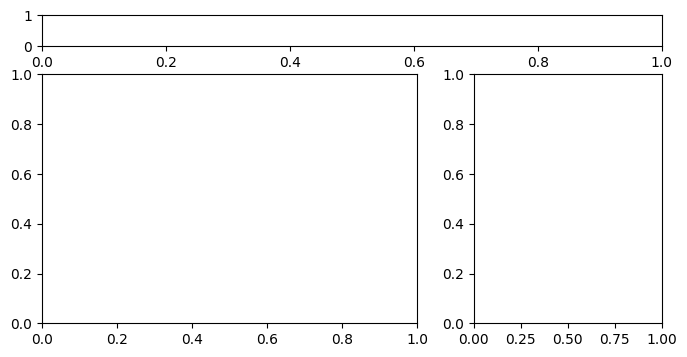

In [19]:
fig = plt.figure(figsize=(8,4))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 8],
    width_ratios=[2, 1]
)

ax_top = fig.add_subplot(gs[0, :])   # top row, full width
ax_left = fig.add_subplot(gs[1, 0])  # bottom-left (wide)
ax_right = fig.add_subplot(gs[1, 1]) # bottom-right (narrow)

panel_spectus_curves(ax_top, ax_left, ax_right, curves, Curve_ref)

restyle_ax(ax_top, legend_font_size= config.ax_label_size)
for ax in [ax_left, ax_right]:
    ax.set_ylim(0.01,0.12)
    restyle_ax(ax)
    
plt.tight_layout()

## Other